# Aubergine HACKaMINeD 2026 — ML Requirements + Bonus Pipeline

This notebook is aligned to the hackathon ML flow:
- Required: Binary fault prediction for 7–10 day horizon, time-aware split, hold-out evaluation, model selection.
- Bonus: Multi-class risk (No Risk / Degradation / Shutdown), anomaly scoring, SHAP explainability, live risk dashboard artifacts.


In [1]:
# ── CELL 1: INSTALL ───────────────────────────────────────────────────
!pip install -q pandas scikit-learn shap matplotlib seaborn xgboost

In [2]:
# ── CELL 2: IMPORTS ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle, json, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    accuracy_score, average_precision_score, precision_recall_curve
)
from xgboost import XGBClassifier
import shap


def safe_binary_auc(y_true, y_prob):
    y_unique = np.unique(pd.Series(y_true).dropna())
    if len(y_unique) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_pr_auc(y_true, y_prob):
    y_unique = np.unique(pd.Series(y_true).dropna())
    if len(y_unique) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def format_metric(val):
    return f'{val:.4f}' if pd.notna(val) else 'N/A (single class in y_true)'


def best_f1_threshold(y_true, y_prob):
    y = np.asarray(y_true)
    p = np.asarray(y_prob)
    if np.unique(y).size < 2 or y.sum() == 0:
        return 0.5, np.nan

    precision, recall, thresholds = precision_recall_curve(y, p)
    if len(thresholds) == 0:
        pred = (p >= 0.5).astype(int)
        return 0.5, f1_score(y, pred, zero_division=0)

    f1_vals = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1_vals))
    return float(thresholds[best_idx]), float(f1_vals[best_idx])


def threshold_for_top_k(scores, k_frac=0.02):
    s = np.asarray(scores)
    if s.size == 0:
        return 0.5, 0
    k = max(1, int(len(s) * k_frac))
    idx = np.argpartition(s, -k)[-k:]
    thr = float(np.min(s[idx]))
    return thr, k



def threshold_for_recall_target(y_true, scores, target_recall=0.20):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)

    if y.size == 0 or np.unique(y).size < 2 or y.sum() == 0:
        return np.nan, np.nan, np.nan

    precision, recall, thresholds = precision_recall_curve(y, s)
    if len(thresholds) == 0:
        return np.nan, np.nan, np.nan

    p = precision[:-1]
    r = recall[:-1]
    t = thresholds

    valid = r >= target_recall
    if not np.any(valid):
        return np.nan, np.nan, np.nan

    idxs = np.where(valid)[0]
    best_idx = idxs[np.argmax(p[idxs])]
    return float(t[best_idx]), float(p[best_idx]), float(r[best_idx])


def apply_threshold(scores, threshold):
    s = np.asarray(scores)
    if s.size == 0:
        return np.array([], dtype=int)
    return (s >= float(threshold)).astype(int)

def maybe_flip_scores(y_true, y_prob, min_gain=0.02):
    y = np.asarray(y_true)
    p = np.asarray(y_prob)
    auc_raw = safe_binary_auc(y, p)
    auc_flip = safe_binary_auc(y, 1 - p)

    if pd.notna(auc_raw) and pd.notna(auc_flip) and (auc_flip > auc_raw + min_gain):
        return 1 - p, True, auc_raw, auc_flip
    return p, False, auc_raw, auc_flip


def precision_recall_at_k(y_true, scores, k_frac=0.01):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(scores)
    n = len(y)
    if n == 0:
        return np.nan, np.nan, 0

    k = max(1, int(n * k_frac))
    idx = np.argsort(-s)[:k]

    tp = int(y[idx].sum())
    precision = tp / k if k > 0 else np.nan
    recall = tp / max(1, int(y.sum()))
    return precision, recall, k


def downsample_negatives(df, target_col, neg_pos_ratio=20, random_state=42):
    pos_df = df[df[target_col] == 1]
    neg_df = df[df[target_col] == 0]

    if len(pos_df) == 0 or len(neg_df) == 0:
        return df.copy()

    keep_neg = min(len(neg_df), len(pos_df) * neg_pos_ratio)
    neg_sample = neg_df.sample(n=keep_neg, random_state=random_state)
    sampled = pd.concat([pos_df, neg_sample], axis=0).sort_values(['inverter_id', 'datetime'])
    return sampled


def per_plant_metrics(source_plant_series, y_true, scores):
    d = pd.DataFrame({
        'plant': pd.Series(source_plant_series).astype(str).values,
        'y': np.asarray(y_true).astype(int),
        's': np.asarray(scores)
    })

    rows = []
    for plant, g in d.groupby('plant'):
        rows.append({
            'plant': plant,
            'support': int(len(g)),
            'positives': int(g['y'].sum()),
            'pos_rate': float(g['y'].mean()),
            'auc': safe_binary_auc(g['y'], g['s']),
            'pr_auc': safe_pr_auc(g['y'], g['s'])
        })
    return pd.DataFrame(rows).sort_values('plant')


def print_binary_report(y_true, y_pred):
    print(
        classification_report(
            y_true, y_pred,
            labels=[0, 1],
            target_names=['Healthy', 'Fault'],
            zero_division=0
        )
    )


def print_multiclass_report(y_true, y_pred):
    print(
        classification_report(
            y_true, y_pred,
            labels=[0, 1, 2],
            target_names=['No Risk', 'Degradation', 'Shutdown'],
            zero_division=0
        )
    )


print('All imports successful!')


All imports successful!


In [3]:
# ── CELL 3: DATA LOADING (PLANT 1 + 2 + 3, DRIVE FOLDER URL) ──────────
# Works in Colab by downloading CSVs from the shared Drive folder URL,
# then auto-discovers required files by filename patterns.

from pathlib import Path
import re
import sys
import subprocess

DATASET_FOLDER_URL = 'https://drive.google.com/drive/folders/1SJWGxeu8NkPU7MEIBAMkbevD7RPq78Kc?usp=sharing'
DOWNLOAD_ROOT = Path('/content/hackathon_data')

EXPECTED_FILES = {
    'P1_LT1': ['icr2-lt1-celestical-10000.73.raws.csv', 'icr2-lt1'],
    'P1_LT2': ['icr2-lt2-celestical-10000.73.raws.csv', 'icr2-lt2'],
    'P2_A':   ['80-1f-12-0f-ac-12.raws.csv', '80-1f-12-0f-ac-12'],
    'P2_B':   ['80-1f-12-0f-ac-bb.raws.csv', '80-1f-12-0f-ac-bb'],
    'P3_A':   ['54-10-ec-8c-14-69.raws.csv', '54-10-ec-8c-14-69'],
    'P3_B':   ['54-10-ec-8c-14-6e.raws.csv', '54-10-ec-8c-14-6e'],
}

EXPECTED_INV_FIELDS = [
    'temp', 'power', 'pv1_power', 'v_ab', 'v_bc', 'v_ca',
    'freq', 'kwh_today', 'op_state', 'alarm_code'
]


def _safe_series(df, col_name, default=np.nan):
    if col_name in df.columns:
        return df[col_name]
    return pd.Series(default, index=df.index)


def _parse_datetime_from_timestamp(ts_series):
    dt = pd.to_datetime(ts_series, unit='ms', errors='coerce')
    if dt.isna().mean() > 0.3:
        dt = pd.to_datetime(ts_series, errors='coerce')
    return dt


def ensure_colab_drive_download(folder_url, output_dir):
    """Download shared Drive folder into Colab runtime using gdown."""
    is_colab = 'google.colab' in sys.modules
    if not is_colab:
        return

    existing = list(output_dir.rglob('*.csv')) if output_dir.exists() else []
    if len(existing) >= 6:
        print(f'Using existing downloaded data in {output_dir} ({len(existing)} csv files found).')
        return

    print('Colab detected. Downloading dataset folder from shared Google Drive URL...')

    try:
        import gdown  # noqa: F401
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'])
        import gdown  # noqa: F401

    output_dir.mkdir(parents=True, exist_ok=True)

    try:
        gdown.download_folder(url=folder_url, output=str(output_dir), quiet=False)
    except TypeError:
        # Compatibility fallback for older gdown signatures.
        gdown.download_folder(folder_url, output=str(output_dir), quiet=False)

    downloaded = list(output_dir.rglob('*.csv'))
    print(f'Download complete. CSV files discovered under download root: {len(downloaded)}')


def discover_plant_files(additional_roots=None):
    roots = [Path.cwd(), DOWNLOAD_ROOT, Path('/content'), Path('/Users/vikas/Desktop/Checking for it')]
    if additional_roots:
        roots = additional_roots + roots

    csv_files = []
    for root in roots:
        if root.exists():
            csv_files.extend(root.rglob('*.csv'))

    # Deduplicate while preserving order.
    seen = set()
    deduped = []
    for p in csv_files:
        k = str(p.resolve())
        if k not in seen:
            seen.add(k)
            deduped.append(p)

    mapping = {}
    for p in deduped:
        name = p.name.lower()
        for label, tokens in EXPECTED_FILES.items():
            if label in mapping:
                continue
            if any(tok in name for tok in tokens):
                mapping[label] = p

    missing = [k for k in EXPECTED_FILES if k not in mapping]
    if missing:
        found_preview = '\n'.join(f'  - {str(x)}' for x in deduped[:80])
        raise FileNotFoundError(
            'Could not auto-discover all required plant files. '
            f'Missing labels: {missing}. '
            f'Current cwd: {Path.cwd()}\nFound CSV files:\n{found_preview}'
        )

    return [(label, mapping[label]) for label in ['P1_LT1', 'P1_LT2', 'P2_A', 'P2_B', 'P3_A', 'P3_B']]


def load_and_melt_csv(file_path, source_label):
    df = pd.read_csv(file_path, low_memory=False)
    if 'timestamp' not in df.columns:
        raise ValueError(f'File missing timestamp column: {file_path}')

    df['datetime'] = _parse_datetime_from_timestamp(df['timestamp'])
    df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)

    inverter_idx = set()
    for c in df.columns:
        m = re.match(r'inverters\[(\d+)\]\.', c)
        if m:
            inverter_idx.add(int(m.group(1)))
    inverter_idx = sorted(inverter_idx)

    print(f"  {source_label:<6} | rows={len(df):>7} | inverters={len(inverter_idx):>2} | {df['datetime'].min().date()} to {df['datetime'].max().date()} | {file_path}")

    out = []
    for i in inverter_idx:
        inv_df = pd.DataFrame()
        inv_df['datetime'] = df['datetime']
        inv_df['inverter_id'] = f'{source_label}_{i}'
        inv_df['source_plant'] = source_label.split('_')[0]

        for field in EXPECTED_INV_FIELDS:
            inv_df[field] = _safe_series(df, f'inverters[{i}].{field}')

        inv_df['ambient_temp'] = _safe_series(df, 'sensors[0].ambient_temp')
        out.append(inv_df)

    return pd.concat(out, ignore_index=True)


print('Preparing dataset sources...')
ensure_colab_drive_download(DATASET_FOLDER_URL, DOWNLOAD_ROOT)

print('Discovering and loading all plant data (Plant 1 + Plant 2 + Plant 3)...')
PLANT_FILES = discover_plant_files()
all_chunks = [load_and_melt_csv(path, label) for label, path in PLANT_FILES]
all_data = pd.concat(all_chunks, ignore_index=True)

print('\nCombined dataset summary:')
print(f'  Shape: {all_data.shape}')
print(f'  Inverters: {all_data["inverter_id"].nunique()}')
print(f'  Date range: {all_data["datetime"].min()} to {all_data["datetime"].max()}')
plant_counts = all_data['source_plant'].value_counts()
print(f'  Plants: {plant_counts.to_dict()}')

if plant_counts.shape[0] < 3:
    raise ValueError(
        'Expected all 3 plants (P1, P2, P3) but fewer were loaded. '
        f'Loaded plants={plant_counts.to_dict()}. '
        'Please verify Google Drive folder contents and file names.'
    )


Preparing dataset sources...
Discovering and loading all plant data (Plant 1 + Plant 2 + Plant 3)...
  P1_LT1 | rows= 189421 | inverters=12 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 1/Copy of ICR2-LT1-Celestical-10000.73.raws.csv
  P1_LT2 | rows= 189213 | inverters=11 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 1/Copy of ICR2-LT2-Celestical-10000.73.raws.csv
  P2_A   | rows= 190899 | inverters= 2 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 2/Copy of 80-1F-12-0F-AC-12.raws.csv
  P2_B   | rows= 187485 | inverters= 5 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 2/Copy of 80-1F-12-0F-AC-BB.raws.csv
  P3_A   | rows= 191060 | inverters= 1 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 3/Copy of 54-10-EC-8C-14-69.raws.csv
  P3_B   | rows= 190845 | inverters= 1 | 2024-03-01 to 2026-03-02 | /Users/vikas/Desktop/Checking for it/Plant 3/Copy of 54-10-EC-8C-14-6

In [4]:
# ── CELL 4: FEATURE ENGINEERING (ROBUST FOR MULTI-PLANT SCHEMAS) ───────
# Includes missing-sensor handling so Plant 2/3 are retained for training.

# Plant-agnostic running filter:
# op_state codes are inconsistent across plants (e.g., P1 uses -1 while P2/P3 use other codes),
# so we use measured inverter power to identify active periods.
raw_power = pd.to_numeric(all_data['power'], errors='coerce').fillna(0.0)
running_mask = (raw_power > 0.0)

# Safety: if power-based filter is too restrictive due parsing issues, keep all rows.
if running_mask.mean() < 0.10:
    running_mask = pd.Series(True, index=all_data.index)

daytime = all_data[running_mask].copy()
daytime = daytime.sort_values(['inverter_id', 'datetime']).reset_index(drop=True)

raw_numeric_cols = [
    'temp', 'power', 'pv1_power', 'v_ab', 'v_bc', 'v_ca',
    'freq', 'kwh_today', 'ambient_temp', 'alarm_code'
]

# Convert to numeric + time-aware imputation per inverter.
for col in raw_numeric_cols:
    daytime[col] = pd.to_numeric(daytime[col], errors='coerce')
    # Forward-fill only to avoid future leakage from backward-fill in time series
    daytime[col] = daytime.groupby('inverter_id')[col].transform(lambda x: x.ffill())

# Fill residual missing values using global medians / safe defaults.
for col in ['temp', 'power', 'pv1_power', 'kwh_today', 'ambient_temp']:
    daytime[col] = daytime[col].fillna(daytime[col].median())

for col in ['v_ab', 'v_bc', 'v_ca', 'freq']:
    daytime[col] = daytime[col].fillna(daytime[col].median()).fillna(0.0)

daytime['alarm_code'] = daytime['alarm_code'].fillna(0.0)

# ── KPI 1: PEER COMPARISON ─────────────────────────────────────────
daytime['median_power_at_time'] = daytime.groupby('datetime')['power'].transform('median')
daytime['power_ratio'] = (daytime['power'] / (daytime['median_power_at_time'] + 1e-6)).clip(0, 2)
daytime.loc[daytime['median_power_at_time'] < 10, 'power_ratio'] = 1.0

daytime['median_temp_at_time'] = daytime.groupby('datetime')['temp'].transform('median')
daytime['temp_deviation'] = daytime['temp'] - daytime['median_temp_at_time']

# ── KPI 2: VOLTAGE IMBALANCE ───────────────────────────────────────
daytime['voltage_mean'] = (daytime['v_ab'] + daytime['v_bc'] + daytime['v_ca']) / 3
daytime['voltage_imbalance'] = (
    daytime[['v_ab', 'v_bc', 'v_ca']].max(axis=1) -
    daytime[['v_ab', 'v_bc', 'v_ca']].min(axis=1)
) / (daytime['voltage_mean'].abs() + 1e-6)

daytime['voltage_imbalance'] = daytime['voltage_imbalance'].replace([np.inf, -np.inf], np.nan).fillna(0.0)

# ── KPI 3: ROLLING FEATURES (24hr window = 288 readings) ──────────
grp = daytime.groupby('inverter_id')
daytime['temp_rolling_mean'] = grp['temp'].transform(lambda x: x.rolling(288, min_periods=1).mean())
daytime['temp_rolling_std'] = grp['temp'].transform(lambda x: x.rolling(288, min_periods=1).std().fillna(0))
daytime['power_rolling_mean'] = grp['power'].transform(lambda x: x.rolling(288, min_periods=1).mean())
daytime['power_ratio_rolling_mean'] = grp['power_ratio'].transform(lambda x: x.rolling(288, min_periods=1).mean())
daytime['voltage_imbalance_rolling'] = grp['voltage_imbalance'].transform(lambda x: x.rolling(288, min_periods=1).mean())

# ── KPI 4: TEMPERATURE SPIKE FLAG ──────────────────────────────────
inv_stats = daytime.groupby('inverter_id')['temp'].agg(['mean', 'std']).reset_index()
inv_stats.columns = ['inverter_id', 'inv_temp_mean', 'inv_temp_std']
daytime = daytime.merge(inv_stats, on='inverter_id', how='left')
daytime['inv_temp_std'] = daytime['inv_temp_std'].fillna(0)
daytime['temp_spike_flag'] = (
    daytime['temp'] > (daytime['inv_temp_mean'] + 2 * daytime['inv_temp_std'])
).astype(int)

# ── KPI 5: ALARM FEATURES (from alarm_code where available) ───────
daytime['alarm_active'] = (daytime['alarm_code'] > 0).astype(int)

# Re-group on the new column to avoid stale GroupBy column snapshots.
alarm_grp = daytime.groupby('inverter_id')['alarm_active']

daytime['alarm_recent_flag'] = alarm_grp.transform(
    lambda x: x.rolling(12, min_periods=1).max()
).astype(int)

daytime['alarm_rolling_rate'] = alarm_grp.transform(
    lambda x: x.rolling(288, min_periods=1).mean()
)

# ── KPI 6: TIME + PLANT CONTEXT ───────────────────────────────────
daytime['hour'] = daytime['datetime'].dt.hour
daytime['month'] = daytime['datetime'].dt.month
daytime['plant_num'] = daytime['source_plant'].str.extract(r'P(\d+)').astype(float).fillna(0).astype(int)

print(f'Features engineered (power-based active filter). Dataset shape: {daytime.shape}')
print(f'Plants retained: {daytime["source_plant"].value_counts().to_dict()}')
print(f'Alarm active rate: {daytime["alarm_active"].mean()*100:.2f}%')
print(f'Voltage imbalance mean: {daytime["voltage_imbalance"].mean():.4f}')


Features engineered (power-based active filter). Dataset shape: (3200053, 34)
Plants retained: {'P1': 2332698, 'P2': 673755, 'P3': 193600}
Alarm active rate: 1.38%
Voltage imbalance mean: 0.0155


In [5]:
# ── CELL 5: LABELS — BINARY + MULTI-CLASS (7 TO 10 DAY WINDOW) ─────────
# BINARY label: will this inverter fault BETWEEN +7 and +10 calendar days? (0 or 1)
# MULTI-CLASS label: max future severity (0/1/2) in that same +7d to +10d interval

WINDOW_START_DAYS = 7
WINDOW_END_DAYS = 10

# is_fault: stricter current-moment fault indicator (reduces noisy positives)
fault_deg_now = (
    (daytime['power_ratio_rolling_mean'] < 0.93) |
    (daytime['temp_rolling_mean'] > 64) |
    ((daytime['alarm_recent_flag'] == 1) & (daytime['power_ratio_rolling_mean'] < 0.96))
)

fault_shutdown_now = (
    (daytime['power_ratio_rolling_mean'] < 0.88) |
    (daytime['temp_rolling_mean'] > 67) |
    ((daytime['alarm_recent_flag'] == 1) & (daytime['power_ratio_rolling_mean'] < 0.92))
)

daytime['is_fault'] = fault_deg_now.astype(int)

# Multi-class severity at current moment
daytime['severity'] = 0
daytime.loc[fault_deg_now, 'severity'] = 1
daytime.loc[fault_shutdown_now, 'severity'] = 2

# Keep full engineered data for live scoring later (before target dropna)
daytime_full = daytime.copy()


def future_window_max_between_by_time(values, datetimes, start_days=7, end_days=10):
    """Max value in future interval [t+start_days, t+end_days], with strict full-horizon check."""
    from collections import deque

    t = pd.to_datetime(datetimes.values).to_numpy(dtype='datetime64[ns]')
    v = np.asarray(values, dtype=float)
    n = len(v)
    out = np.full(n, np.nan, dtype=float)

    if n == 0:
        return out

    start_delta = np.timedelta64(start_days, 'D')
    end_delta = np.timedelta64(end_days, 'D')

    # Monotonic interval bounds per row (on sorted timestamps)
    left = np.searchsorted(t, t + start_delta, side='left')
    right = np.searchsorted(t, t + end_delta, side='right')

    # Require complete +end_days horizon to avoid label truncation leakage
    full_horizon_mask = t <= (t.max() - end_delta)

    dq = deque()
    add_ptr = 0

    for i in range(n):
        L = int(left[i])
        R = int(right[i])

        # Expand right edge and maintain decreasing deque of candidate maxima
        while add_ptr < R:
            curr = v[add_ptr]
            while dq and v[dq[-1]] <= curr:
                dq.pop()
            dq.append(add_ptr)
            add_ptr += 1

        # Drop elements that fell left of window
        while dq and dq[0] < L:
            dq.popleft()

        if full_horizon_mask[i] and L < R and dq:
            out[i] = v[dq[0]]

    return out


# Binary target: any fault between +7 and +10 days?
daytime['fault_in_7to10days'] = daytime.groupby('inverter_id', group_keys=False).apply(
    lambda g: pd.Series(
        future_window_max_between_by_time(
            g['is_fault'], g['datetime'],
            start_days=WINDOW_START_DAYS,
            end_days=WINDOW_END_DAYS
        ),
        index=g.index
    )
)

# Multi-class target: max severity between +7 and +10 days
daytime['multiclass_target'] = daytime.groupby('inverter_id', group_keys=False).apply(
    lambda g: pd.Series(
        future_window_max_between_by_time(
            g['severity'], g['datetime'],
            start_days=WINDOW_START_DAYS,
            end_days=WINDOW_END_DAYS
        ),
        index=g.index
    )
)

# Drop rows where full +10 day horizon is unavailable
daytime = daytime.dropna(subset=['fault_in_7to10days', 'multiclass_target'])
daytime['fault_in_7to10days'] = daytime['fault_in_7to10days'].astype(int)
daytime['multiclass_target'] = daytime['multiclass_target'].astype(int)

print(f'Dataset shape: {daytime.shape}')
print(f'Window definition: +{WINDOW_START_DAYS}d to +{WINDOW_END_DAYS}d')
print(f'\nBinary label distribution:')
print(daytime['fault_in_7to10days'].value_counts())
print(f'Positive rate: {daytime["fault_in_7to10days"].mean()*100:.2f}%')
print(f'\nMulti-class label distribution:')
print(daytime['multiclass_target'].value_counts().sort_index())
print('(0=No Risk, 1=Degradation Risk, 2=Shutdown Risk)')


Dataset shape: (3121423, 38)
Window definition: +7d to +10d

Binary label distribution:
fault_in_7to10days
0    2858919
1     262504
Name: count, dtype: int64
Positive rate: 8.41%

Multi-class label distribution:
multiclass_target
0    2858919
1     114609
2     147895
Name: count, dtype: int64
(0=No Risk, 1=Degradation Risk, 2=Shutdown Risk)


In [6]:
# ── CELL 6: ANOMALY DETECTION HELPERS (FIT AFTER SPLIT TO AVOID LEAKAGE) ─
ANOMALY_FEATURES = [
    'temp', 'power', 'power_ratio', 'temp_deviation',
    'voltage_imbalance', 'temp_rolling_mean',
    'power_ratio_rolling_mean', 'alarm_rolling_rate'
]


def fit_iso_on_train_and_score(train_df, other_dfs):
    # Fit IsolationForest on healthy TRAIN rows; impute with train medians (not global).
    healthy_train = train_df[train_df['is_fault'] == 0][ANOMALY_FEATURES].copy()
    if healthy_train.empty:
        healthy_train = train_df[ANOMALY_FEATURES].copy()

    train_medians = healthy_train.median(numeric_only=True)
    healthy_train = healthy_train.fillna(train_medians).fillna(0.0)

    iso = IsolationForest(
        n_estimators=100,
        contamination=0.02,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(healthy_train)

    def add_scores(df):
        scored = df.copy()
        anomaly_input = scored[ANOMALY_FEATURES].fillna(train_medians).fillna(0.0)
        scored['anomaly_flag'] = (iso.predict(anomaly_input) == -1).astype(int)
        scored['anomaly_score'] = -iso.score_samples(anomaly_input)
        return scored

    scored_train = add_scores(train_df)
    scored_others = [add_scores(d) for d in other_dfs]
    return iso, scored_train, scored_others


print('Anomaly helper ready. Model fitting will happen after time-based split.')


Anomaly helper ready. Model fitting will happen after time-based split.


In [7]:
# ── CELL 7: FEATURE LIST + ADAPTIVE STRICT PER-INVERTER TIME SPLIT ────
TELEMETRY_FEATURES = [
    'temp', 'power', 'pv1_power', 'v_ab', 'v_bc', 'v_ca',
    'freq', 'kwh_today', 'ambient_temp'
]

KPI_FEATURES_BASE = [
    'power_ratio',
    'temp_deviation',
    'voltage_imbalance',
    'temp_spike_flag',
    'temp_rolling_mean',
    'temp_rolling_std',
    'power_rolling_mean',
    'power_ratio_rolling_mean',
    'voltage_imbalance_rolling',
    'alarm_active',
    'alarm_recent_flag',
    'alarm_rolling_rate',
    'hour', 'month', 'plant_num'
]

BASE_FEATURES = TELEMETRY_FEATURES + KPI_FEATURES_BASE
TARGET = 'fault_in_7to10days'

TRAIN_FRAC = 0.70
DEV_FRAC = 0.15

# Start with strict config, then relax minimally if strict all-plant split fails.
SPLIT_ATTEMPTS = [
    {'purge_days': 7, 'min_rows': 40},
    {'purge_days': 5, 'min_rows': 30},
    {'purge_days': 3, 'min_rows': 20},
    {'purge_days': 1, 'min_rows': 10},
    {'purge_days': 0, 'min_rows': 10},
]

model_df = daytime[BASE_FEATURES + [TARGET, 'multiclass_target', 'datetime', 'inverter_id', 'source_plant', 'is_fault']].copy()
model_df = model_df.sort_values(['inverter_id', 'datetime']).reset_index(drop=True)

expected_plants = ['P1', 'P2', 'P3']
available_plants = sorted(model_df['source_plant'].astype(str).unique().tolist())
missing_in_loaded = sorted(set(expected_plants) - set(available_plants))
if missing_in_loaded:
    raise ValueError(
        'Loaded data does not include all expected plants before split. '
        f'expected={expected_plants}, loaded={available_plants}, missing={missing_in_loaded}. '
        'Recheck cell 3 loading and cell 4 running filter.'
    )


def split_one_inverter(g, train_frac=0.70, dev_frac=0.15, purge_days=7, min_rows=40):
    g = g.sort_values('datetime').copy()
    n = len(g)

    if n < (3 * min_rows):
        return None

    i = int(n * train_frac)
    j = int(n * (train_frac + dev_frac))

    i = max(min_rows, min(n - 2 * min_rows, i))
    j = max(i + min_rows, min(n - min_rows, j))

    train_end_time = g.iloc[i - 1]['datetime']
    dev_start_raw = g.iloc[i]['datetime']
    dev_end_time = g.iloc[j - 1]['datetime']
    test_start_raw = g.iloc[j]['datetime']

    purge_delta = pd.Timedelta(days=purge_days)
    dev_start_time = dev_start_raw + purge_delta
    test_start_time = test_start_raw + purge_delta

    train_part = g[g['datetime'] <= train_end_time].copy()
    dev_part = g[(g['datetime'] >= dev_start_time) & (g['datetime'] <= dev_end_time)].copy()
    test_part = g[g['datetime'] >= test_start_time].copy()

    if len(train_part) < min_rows or len(dev_part) < min_rows or len(test_part) < min_rows:
        return None

    return train_part, dev_part, test_part


def try_build_split(df, purge_days, min_rows):
    train_parts, dev_parts, test_parts = [], [], []
    dropped = []

    for inv_id, g in df.groupby('inverter_id', sort=False):
        out = split_one_inverter(
            g,
            train_frac=TRAIN_FRAC,
            dev_frac=DEV_FRAC,
            purge_days=purge_days,
            min_rows=min_rows
        )
        if out is None:
            dropped.append(inv_id)
            continue
        tr, dv, te = out
        train_parts.append(tr)
        dev_parts.append(dv)
        test_parts.append(te)

    if not train_parts or not dev_parts or not test_parts:
        return None

    train_df_ = pd.concat(train_parts, ignore_index=False).sort_values(['inverter_id', 'datetime'])
    dev_df_ = pd.concat(dev_parts, ignore_index=False).sort_values(['inverter_id', 'datetime'])
    test_df_ = pd.concat(test_parts, ignore_index=False).sort_values(['inverter_id', 'datetime'])

    split_stats_ = {
        'train': {'pos': int(train_df_[TARGET].sum()), 'neg': int((train_df_[TARGET] == 0).sum()), 'total': int(len(train_df_))},
        'dev': {'pos': int(dev_df_[TARGET].sum()), 'neg': int((dev_df_[TARGET] == 0).sum()), 'total': int(len(dev_df_))},
        'test': {'pos': int(test_df_[TARGET].sum()), 'neg': int((test_df_[TARGET] == 0).sum()), 'total': int(len(test_df_))},
    }

    # Binary presence per split.
    for split_name, st in split_stats_.items():
        if st['pos'] == 0 or st['neg'] == 0:
            return None

    train_plants = sorted(train_df_['source_plant'].astype(str).unique().tolist())
    dev_plants = sorted(dev_df_['source_plant'].astype(str).unique().tolist())
    test_plants = sorted(test_df_['source_plant'].astype(str).unique().tolist())

    missing_train = sorted(set(expected_plants) - set(train_plants))
    missing_dev = sorted(set(expected_plants) - set(dev_plants))
    missing_test = sorted(set(expected_plants) - set(test_plants))

    if missing_train or missing_dev or missing_test:
        return {
            'ok': False,
            'reason': 'plant_coverage',
            'train_plants': train_plants,
            'dev_plants': dev_plants,
            'test_plants': test_plants,
            'missing_train': missing_train,
            'missing_dev': missing_dev,
            'missing_test': missing_test,
            'dropped': dropped,
            'stats': split_stats_,
        }

    return {
        'ok': True,
        'train_df': train_df_,
        'dev_df': dev_df_,
        'test_df': test_df_,
        'stats': split_stats_,
        'dropped': dropped,
        'train_plants': train_plants,
        'dev_plants': dev_plants,
        'test_plants': test_plants,
    }


chosen = None
attempt_logs = []
for cfg in SPLIT_ATTEMPTS:
    out = try_build_split(model_df, purge_days=cfg['purge_days'], min_rows=cfg['min_rows'])
    log = {'purge_days': cfg['purge_days'], 'min_rows': cfg['min_rows']}
    if out is None:
        log['status'] = 'invalid_or_single_class'
    elif not out['ok']:
        log['status'] = 'missing_plants'
        log['missing_train'] = out['missing_train']
        log['missing_dev'] = out['missing_dev']
        log['missing_test'] = out['missing_test']
    else:
        log['status'] = 'accepted'
        chosen = (cfg, out)
        attempt_logs.append(log)
        break
    attempt_logs.append(log)

if chosen is None:
    raise ValueError(
        'Could not build strict cross-plant split after adaptive attempts. '
        f'Attempts={attempt_logs}. '
        'Check data loading/filtering for P2/P3 and reduce constraints.'
    )

cfg_used, split_out = chosen
PURGE_DAYS_USED = cfg_used['purge_days']
MIN_ROWS_USED = cfg_used['min_rows']

train_df = split_out['train_df']
dev_df = split_out['dev_df']
test_df = split_out['test_df']
split_stats = split_out['stats']

# Fit anomaly model strictly on train, then score dev/test.
iso_forest, train_df, [dev_df, test_df] = fit_iso_on_train_and_score(train_df, [dev_df, test_df])

# Add one-hot plant features.
plant_cols = sorted(
    set(pd.get_dummies(train_df['source_plant'], prefix='plant').columns)
    | set(pd.get_dummies(dev_df['source_plant'], prefix='plant').columns)
    | set(pd.get_dummies(test_df['source_plant'], prefix='plant').columns)
)

for d in (train_df, dev_df, test_df):
    dummies = pd.get_dummies(d['source_plant'], prefix='plant').reindex(columns=plant_cols, fill_value=0)
    d[plant_cols] = dummies.astype(float)

PLANT_FEATURES = plant_cols
KPI_FEATURES = KPI_FEATURES_BASE + ['anomaly_score']
CORE_FEATURES = TELEMETRY_FEATURES + KPI_FEATURES
FEATURES = CORE_FEATURES + PLANT_FEATURES

train_feature_medians = train_df[FEATURES].median(numeric_only=True)
for d in (train_df, dev_df, test_df):
    d[FEATURES] = d[FEATURES].fillna(train_feature_medians).fillna(0.0)

X_train, y_train, ym_train = train_df[FEATURES], train_df[TARGET], train_df['multiclass_target']
X_dev, y_dev, ym_dev = dev_df[FEATURES], dev_df[TARGET], dev_df['multiclass_target']
X_test, y_test, ym_test = test_df[FEATURES], test_df[TARGET], test_df['multiclass_target']

model_df = pd.concat([train_df, dev_df, test_df], axis=0).sort_index()

print('Split mode: per_inverter_chronological_with_adaptive_strict_coverage')
print(f'Adaptive attempts: {attempt_logs}')
print(f'Chosen config: purge_days={PURGE_DAYS_USED}, min_rows={MIN_ROWS_USED}')
print(f'Dropped inverters: {len(split_out["dropped"])}')
if split_out['dropped']:
    print(f'  Example dropped: {split_out["dropped"][:5]}')

print(f'Class counts (train/dev/test): {split_stats}')
print(f'Train : {X_train.shape} | fault rate: {y_train.mean()*100:.3f}% | {train_df["datetime"].min()} to {train_df["datetime"].max()}')
print(f'Dev   : {X_dev.shape}   | fault rate: {y_dev.mean()*100:.3f}% | {dev_df["datetime"].min()} to {dev_df["datetime"].max()}')
print(f'Test  : {X_test.shape}  | fault rate: {y_test.mean()*100:.3f}% | {test_df["datetime"].min()} to {test_df["datetime"].max()}')

print('\nPlant mix in splits:')
print(f'  Train: {train_df["source_plant"].value_counts().to_dict()}')
print(f'  Dev  : {dev_df["source_plant"].value_counts().to_dict()}')
print(f'  Test : {test_df["source_plant"].value_counts().to_dict()}')

print(f'\nTotal features: {len(FEATURES)}')
print(f'  Core numeric: {len(CORE_FEATURES)}')
print(f'  Plant one-hot: {len(PLANT_FEATURES)} -> {PLANT_FEATURES}')
print(f'  Anomaly flag rates (train/dev/test): {train_df["anomaly_flag"].mean()*100:.2f}% / {dev_df["anomaly_flag"].mean()*100:.2f}% / {test_df["anomaly_flag"].mean()*100:.2f}%')


Split mode: per_inverter_chronological_with_adaptive_strict_coverage
Adaptive attempts: [{'purge_days': 7, 'min_rows': 40, 'status': 'accepted'}]
Chosen config: purge_days=7, min_rows=40
Dropped inverters: 0
Class counts (train/dev/test): {'train': {'pos': 179187, 'neg': 2005795, 'total': 2184982}, 'dev': {'pos': 48276, 'neg': 386401, 'total': 434677}, 'test': {'pos': 29571, 'neg': 409685, 'total': 439256}}
Train : (2184982, 28) | fault rate: 8.201% | 2024-03-01 06:35:01 to 2025-07-25 13:55:05
Dev   : (434677, 28)   | fault rate: 11.106% | 2025-07-20 16:50:01 to 2025-11-04 09:05:07
Test  : (439256, 28)  | fault rate: 6.732% | 2025-10-30 09:20:01 to 2026-02-20 11:15:06

Plant mix in splits:
  Train: {'P1': 1592692, 'P2': 460544, 'P3': 131746}
  Dev  : {'P1': 316862, 'P2': 91612, 'P3': 26203}
  Test : {'P1': 320595, 'P2': 92287, 'P3': 26374}

Total features: 28
  Core numeric: 25
  Plant one-hot: 3 -> ['plant_P1', 'plant_P2', 'plant_P3']
  Anomaly flag rates (train/dev/test): 5.26% / 3.8

In [8]:
# ── CELL 8: QUICK BASELINE (FAST, DOWNSAMPLED) ─────────────────────────
print('Training quick XGBoost baseline on downsampled train...')

NEG_POS_RATIO = 20
ALERT_RATE = 0.01  # top 1% highest-risk readings become alerts

train_fit_df = downsample_negatives(train_df, TARGET, neg_pos_ratio=NEG_POS_RATIO, random_state=42)
X_train_fit = train_fit_df[FEATURES]
y_train_fit = train_fit_df[TARGET]

spw_fit = max(1.0, (len(y_train_fit) - y_train_fit.sum()) / max(1, y_train_fit.sum()))

xgb_base = XGBClassifier(
    n_estimators=220,
    max_depth=4,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=8,
    gamma=1.0,
    reg_alpha=1.0,
    reg_lambda=12.0,
    tree_method='hist',
    random_state=42,
    eval_metric='aucpr',
    scale_pos_weight=spw_fit,
    early_stopping_rounds=25,
    verbosity=0
)

xgb_base.fit(X_train_fit, y_train_fit, eval_set=[(X_dev, y_dev)], verbose=False)

dev_probs_raw = xgb_base.predict_proba(X_dev)[:, 1]

# Dev-driven flip rule (when close): prefer flipped scores if dev AUC is even slightly better.
train_probs_raw = xgb_base.predict_proba(X_train_fit)[:, 1]
train_auc_raw = safe_binary_auc(y_train_fit, train_probs_raw)
train_auc_flip = safe_binary_auc(y_train_fit, 1 - train_probs_raw)
dev_auc_raw = safe_binary_auc(y_dev, dev_probs_raw)
dev_auc_flip = safe_binary_auc(y_dev, 1 - dev_probs_raw)

base_flip = (
    pd.notna(dev_auc_raw) and pd.notna(dev_auc_flip) and
    (dev_auc_flip > dev_auc_raw + 0.001)
)

dev_probs_base = (1 - dev_probs_raw) if base_flip else dev_probs_raw
base_threshold, base_k = threshold_for_top_k(dev_probs_base, k_frac=ALERT_RATE)
dev_preds_base = (dev_probs_base >= base_threshold).astype(int)

dev_auc_base = safe_binary_auc(y_dev, dev_probs_base)
dev_pr_auc_base = safe_pr_auc(y_dev, dev_probs_base)
dev_f1_base = f1_score(y_dev, dev_preds_base, zero_division=0)
p_at_k_base, r_at_k_base, _ = precision_recall_at_k(y_dev, dev_probs_base, k_frac=ALERT_RATE)

print_binary_report(y_dev, dev_preds_base)
print(f'Baseline train rows used: {len(train_fit_df):,} (downsampled from {len(train_df):,})')
print(f'Baseline AUC(raw): {format_metric(dev_auc_raw)} | AUC(flipped): {format_metric(dev_auc_flip)} | Flipped used: {base_flip}')
print(f'Baseline Dev AUC(used): {format_metric(dev_auc_base)} | Dev PR-AUC: {format_metric(dev_pr_auc_base)} | Dev F1@thr: {format_metric(dev_f1_base)}')
print(f'Baseline threshold via top-{ALERT_RATE*100:.1f}% alerts: {base_threshold:.4f} ({base_k} alerts)')
print(f'Baseline Precision@top{ALERT_RATE*100:.1f}%: {format_metric(p_at_k_base)} | Recall@top{ALERT_RATE*100:.1f}%: {format_metric(r_at_k_base)}')


Training quick XGBoost baseline on downsampled train...
              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95    386401
       Fault       1.00      0.10      0.17     48276

    accuracy                           0.90    434677
   macro avg       0.95      0.55      0.56    434677
weighted avg       0.91      0.90      0.86    434677

Baseline train rows used: 2,184,982 (downsampled from 2,184,982)
Baseline AUC(raw): 0.9498 | AUC(flipped): 0.0502 | Flipped used: False
Baseline Dev AUC(used): 0.9498 | Dev PR-AUC: 0.8667 | Dev F1@thr: 0.1744
Baseline threshold via top-1.0% alerts: 0.9976 (4346 alerts)
Baseline Precision@top1.0%: 1.0000 | Recall@top1.0%: 0.0900


In [9]:
# ── CELL 9: PRODUCTION FAST MODEL (REGULARIZED + EARLY STOPPING) ──────
print('Training production XGBoost (requirements + bonus mode)...')

NEG_POS_RATIO = 20
ALERT_RATE = 0.01      # report and fallback reference
TARGET_RECALL = 0.20   # target minimum recall on dev

train_fit_df = downsample_negatives(train_df, TARGET, neg_pos_ratio=NEG_POS_RATIO, random_state=42)
X_train_fit = train_fit_df[FEATURES]
y_train_fit = train_fit_df[TARGET]

spw_fit = max(1.0, (len(y_train_fit) - y_train_fit.sum()) / max(1, y_train_fit.sum()))

best_xgb_params = {
    'n_estimators': 360,
    'max_depth': 4,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'gamma': 1.2,
    'reg_alpha': 2.0,
    'reg_lambda': 15.0,
}

best_model_name = 'XGBoost'
best_model = XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    verbosity=0,
    tree_method='hist',
    scale_pos_weight=spw_fit,
    early_stopping_rounds=30,
    **best_xgb_params
)
best_model.fit(X_train_fit, y_train_fit, eval_set=[(X_dev, y_dev)], verbose=False)

best_iteration = getattr(best_model, 'best_iteration', None)
if best_iteration is None or best_iteration <= 0:
    best_n_estimators = int(best_xgb_params['n_estimators'])
else:
    best_n_estimators = int(best_iteration) + 1

dev_probs_raw = best_model.predict_proba(X_dev)[:, 1]
train_probe_probs_raw = best_model.predict_proba(X_train_fit)[:, 1]

train_auc_raw = safe_binary_auc(y_train_fit, train_probe_probs_raw)
train_auc_flip = safe_binary_auc(y_train_fit, 1 - train_probe_probs_raw)
dev_auc_raw = safe_binary_auc(y_dev, dev_probs_raw)
dev_auc_flip = safe_binary_auc(y_dev, 1 - dev_probs_raw)

# Dev-driven flip rule.
score_flipped = (
    pd.notna(dev_auc_raw) and pd.notna(dev_auc_flip) and
    (dev_auc_flip > dev_auc_raw + 0.001)
)

dev_probs = (1 - dev_probs_raw) if score_flipped else dev_probs_raw
y_dev_arr = np.asarray(y_dev).astype(int)
true_pos_dev = int(y_dev_arr.sum())

# Bound acceptable predicted-positive rate to avoid degenerate all-healthy/all-fault thresholds.
min_pred_rate = max(0.002, float(y_dev.mean() * 0.5))
max_pred_rate = min(0.05, max(0.02, float(y_dev.mean() * 4.0)))
if max_pred_rate <= min_pred_rate:
    max_pred_rate = min(0.08, min_pred_rate + 0.01)

def evaluate_threshold(y_true_arr, probs, thr, strategy):
    preds = apply_threshold(probs, thr)
    pred_pos = int(preds.sum())
    tp = int(((preds == 1) & (y_true_arr == 1)).sum())
    precision = tp / pred_pos if pred_pos > 0 else 0.0
    recall = tp / max(1, int(y_true_arr.sum()))
    f1 = f1_score(y_true_arr, preds, zero_division=0)
    pred_rate = pred_pos / max(1, len(preds))
    return {
        'strategy': strategy,
        'threshold': float(thr),
        'pred_pos': pred_pos,
        'pred_rate': float(pred_rate),
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
    }

thr_recall, prec_at_rec, rec_at_rec = threshold_for_recall_target(y_dev, dev_probs, target_recall=TARGET_RECALL)
thr_topk, topk_n = threshold_for_top_k(dev_probs, k_frac=ALERT_RATE)

candidates = []
if pd.notna(thr_recall):
    candidates.append(evaluate_threshold(y_dev_arr, dev_probs, thr_recall, f'recall_target_{TARGET_RECALL:.2f}'))
candidates.append(evaluate_threshold(y_dev_arr, dev_probs, thr_topk, f'top_{ALERT_RATE*100:.1f}pct'))

cand_df = pd.DataFrame(candidates)
cand_df['in_band'] = (cand_df['pred_rate'] >= min_pred_rate) & (cand_df['pred_rate'] <= max_pred_rate)

# Prefer in-band threshold first, then higher F1.
cand_df = cand_df.sort_values(['in_band', 'f1'], ascending=[False, False]).reset_index(drop=True)
selected = cand_df.iloc[0]

best_threshold = float(selected['threshold'])
threshold_strategy = str(selected['strategy'])
dev_preds = apply_threshold(dev_probs, best_threshold)

# Hard guard on dev to ensure non-degenerate predictions.
dev_pred_rate = float(dev_preds.mean())
if (dev_pred_rate < min_pred_rate) or (dev_pred_rate > max_pred_rate):
    best_threshold = float(thr_topk)
    threshold_strategy = threshold_strategy + '+hard_topk_guard'
    dev_preds = apply_threshold(dev_probs, best_threshold)
    dev_pred_rate = float(dev_preds.mean())

dev_auc = safe_binary_auc(y_dev, dev_probs)
dev_pr_auc = safe_pr_auc(y_dev, dev_probs)
dev_f1 = f1_score(y_dev, dev_preds, zero_division=0)

dev_pred_pos = int(dev_preds.sum())
dev_true_pos = int(y_dev.sum())

# Deployment alert-rate transfer with clipping to non-degenerate band.
deployment_alert_rate = float(np.clip(dev_pred_rate, min_pred_rate, max_pred_rate))
deployment_quantile = float(max(0.0, 1.0 - deployment_alert_rate))

p_at_1, r_at_1, k1 = precision_recall_at_k(y_dev, dev_probs, k_frac=0.01)
p_at_2, r_at_2, k2 = precision_recall_at_k(y_dev, dev_probs, k_frac=0.02)

print_binary_report(y_dev, dev_preds)
print(f'Train rows used: {len(train_fit_df):,} / {len(train_df):,} (downsample ratio target={NEG_POS_RATIO}:1)')
print(f'Dev AUC(raw): {format_metric(dev_auc_raw)} | Dev AUC(flipped): {format_metric(dev_auc_flip)} | Score flipped: {score_flipped}')
print(f'Dev PR-AUC: {format_metric(dev_pr_auc)} | Dev AUC(used): {format_metric(dev_auc)} | Dev F1@thr: {format_metric(dev_f1)}')
print(f'Threshold strategy: {threshold_strategy}')
if pd.notna(thr_recall):
    print(f'  Recall-target candidate ({TARGET_RECALL:.2f}): thr={thr_recall:.4f} | precision={format_metric(prec_at_rec)} | recall={format_metric(rec_at_rec)}')
print(f'  Top-{ALERT_RATE*100:.1f}% candidate: thr={thr_topk:.4f} ({topk_n} points)')
print('Candidate thresholds:')
print(cand_df[['strategy','threshold','pred_rate','precision','recall','f1','in_band']].to_string(index=False))
print(f'  Final threshold on dev: {best_threshold:.4f} | Dev predicted faults: {dev_pred_pos} / {len(y_dev)} | Dev true faults: {dev_true_pos}')
print(f'  Allowed pred-rate band: [{min_pred_rate:.4f}, {max_pred_rate:.4f}]')
print(f'  Deployment alert rate: {deployment_alert_rate*100:.3f}% | deployment quantile={deployment_quantile:.4f}')
print(f'Precision@{k1}: {format_metric(p_at_1)} | Recall@{k1}: {format_metric(r_at_1)}')
print(f'Precision@{k2}: {format_metric(p_at_2)} | Recall@{k2}: {format_metric(r_at_2)}')

print('Per-plant dev metrics:')
print(per_plant_metrics(dev_df['source_plant'], y_dev, dev_probs).to_string(index=False))

selection_df = pd.DataFrame([{
    'candidate': 'xgb_regularized_single',
    'dev_pr_auc': dev_pr_auc,
    'dev_auc': dev_auc,
    'dev_f1': dev_f1,
    'threshold': float(best_threshold),
    'threshold_strategy': threshold_strategy,
    'flip_used': bool(score_flipped),
    'best_n_estimators': int(best_n_estimators),
    'alert_rate': ALERT_RATE,
    'min_pred_rate': min_pred_rate,
    'max_pred_rate': max_pred_rate,
    'deployment_alert_rate': deployment_alert_rate,
    'deployment_quantile': deployment_quantile,
}])

print('\n' + '='*70)
print('MODEL SELECTION TABLE (REQUIREMENTS + BONUS MODE)')
print('='*70)
print(selection_df.to_string(index=False))
print('\nSelected production model:')
print(f'  Name: {best_model_name}')
print(f'  n_estimators (best): {best_n_estimators}')
print(f'  Decision threshold: {best_threshold:.4f} ({threshold_strategy})')
print(f'  Score flipped: {score_flipped}')


Training production XGBoost (requirements + bonus mode)...
              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95    386401
       Fault       1.00      0.11      0.20     48276

    accuracy                           0.90    434677
   macro avg       0.95      0.56      0.57    434677
weighted avg       0.91      0.90      0.86    434677

Train rows used: 2,184,982 / 2,184,982 (downsample ratio target=20:1)
Dev AUC(raw): 0.9478 | Dev AUC(flipped): 0.0522 | Score flipped: False
Dev PR-AUC: 0.8665 | Dev AUC(used): 0.9478 | Dev F1@thr: 0.2017
Threshold strategy: recall_target_0.20+hard_topk_guard
  Recall-target candidate (0.20): thr=0.9926 | precision=1.0000 | recall=0.2092
  Top-1.0% candidate: thr=0.9934 (4346 points)
Candidate thresholds:
          strategy  threshold  pred_rate  precision   recall       f1  in_band
recall_target_0.20   0.992617   0.023238        1.0 0.209234 0.346061    False
        top_1.0pct   0.993399   0.012460       

In [10]:
# ── CELL 10: FINAL HOLD-OUT EVALUATION (REQUIREMENTS + BONUS MODE) ────
print('='*70)
print('FINAL HOLD-OUT TEST SET EVALUATION')
print('Selected model: XGBoost (fast robust)')
print('Test set is used only in this cell for final unbiased score')
print('='*70)

train_final_df = pd.concat([train_df, dev_df], axis=0).sort_values(['inverter_id', 'datetime'])

X_train_final_full = train_final_df[FEATURES]
y_train_final_full = train_final_df[TARGET]
ym_train_final = train_final_df['multiclass_target']

train_final_fit = downsample_negatives(train_final_df, TARGET, neg_pos_ratio=NEG_POS_RATIO, random_state=42)
X_train_final_fit = train_final_fit[FEATURES]
y_train_final_fit = train_final_fit[TARGET]

spw_final = max(1.0, (len(y_train_final_fit) - y_train_final_fit.sum()) / max(1, y_train_final_fit.sum()))

final_params = best_xgb_params.copy()
final_params['n_estimators'] = int(best_n_estimators)

best_model_final = XGBClassifier(
    random_state=42,
    eval_metric='aucpr',
    verbosity=0,
    tree_method='hist',
    scale_pos_weight=spw_final,
    **final_params
)
best_model_final.fit(X_train_final_fit, y_train_final_fit)

test_probs_raw = best_model_final.predict_proba(X_test)[:, 1]
test_probs = (1 - test_probs_raw) if score_flipped else test_probs_raw

used_threshold = float(best_threshold)
threshold_strategy_used = 'dev_threshold'
test_preds = apply_threshold(test_probs, used_threshold)
test_pred_rate = float(test_preds.mean())

# Single stable rate-guard fallback.
if (test_pred_rate < min_pred_rate) or (test_pred_rate > max_pred_rate):
    k_force = max(1, int(len(test_probs) * deployment_alert_rate))
    idx_force = np.argsort(-test_probs)[:k_force]
    test_preds = np.zeros(len(test_probs), dtype=int)
    test_preds[idx_force] = 1
    used_threshold = float(np.min(test_probs[idx_force]))
    threshold_strategy_used = 'rate_guard_topk'
    test_pred_rate = float(test_preds.mean())

threshold_fallback_used = threshold_strategy_used != 'dev_threshold'

test_auc = safe_binary_auc(y_test, test_probs)
test_pr_auc = safe_pr_auc(y_test, test_probs)
auc_raw = safe_binary_auc(y_test, test_probs_raw)
auc_flipped = safe_binary_auc(y_test, 1 - test_probs_raw)

print('\nBinary Classification (Healthy vs Fault):')
print_binary_report(y_test, test_preds)
print(f'AUC(raw): {format_metric(auc_raw)} | AUC(flipped): {format_metric(auc_flipped)} | Flipped used: {score_flipped}')
print(f'AUC(used): {format_metric(test_auc)}')
print(f'PR-AUC(used): {format_metric(test_pr_auc)}')
print(f'Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%')
print(f'Dev threshold source: {threshold_strategy}')
print(f'Test threshold strategy used: {threshold_strategy_used}')
print(f'Threshold value used: {used_threshold:.4f} | Fallback applied: {threshold_fallback_used}')
print(f'Predicted faults on test: {int(test_preds.sum())} / {len(y_test)} | True faults: {int(y_test.sum())}')
print(f'Test predicted rate: {test_pred_rate:.4f} | Allowed band: [{min_pred_rate:.4f}, {max_pred_rate:.4f}]')

p_at_1, r_at_1, k1 = precision_recall_at_k(y_test, test_probs, k_frac=0.01)
p_at_2, r_at_2, k2 = precision_recall_at_k(y_test, test_probs, k_frac=0.02)
print(f'Precision@{k1}: {format_metric(p_at_1)} | Recall@{k1}: {format_metric(r_at_1)}')
print(f'Precision@{k2}: {format_metric(p_at_2)} | Recall@{k2}: {format_metric(r_at_2)}')

print('\nPer-plant TEST metrics:')
plant_test_df = per_plant_metrics(test_df['source_plant'], y_test, test_probs)
print(plant_test_df.to_string(index=False))

train_probs_raw = best_model_final.predict_proba(X_train_final_full)[:, 1]
train_probs_final = (1 - train_probs_raw) if score_flipped else train_probs_raw
train_preds_final = apply_threshold(train_probs_final, used_threshold)
train_f1 = f1_score(y_train_final_full, train_preds_final, zero_division=0)
test_f1 = f1_score(y_test, test_preds, zero_division=0)
print(f'\nBias/Variance (F1): Train={train_f1:.4f} | Test={test_f1:.4f} | Gap={abs(train_f1-test_f1):.4f}')
if train_f1 == 0 and test_f1 == 0:
    print('Model collapse warning: both train and test F1 are zero. Revisit labels/features or threshold strategy.')
elif abs(train_f1 - test_f1) < 0.05:
    print('Good fit: no major train-test gap')
else:
    print('Possible overfitting: consider stronger regularization or alternative label design')

print('\n' + '='*70)
print('MULTI-CLASS EVALUATION (BONUS): No Risk / Degradation / Shutdown')
print('='*70)

multi_params = {
    'n_estimators': max(180, int(best_n_estimators)),
    'max_depth': 4,
    'learning_rate': 0.06,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'min_child_weight': 6,
    'reg_alpha': 1.0,
    'reg_lambda': 10.0,
}

xgb_multi = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    tree_method='hist',
    **multi_params
)
mc_counts = ym_train_final.value_counts().sort_index()
mc_total = float(mc_counts.sum())
mc_classes = sorted(mc_counts.index.tolist())
mc_class_weights = {int(cls): float(mc_total / (len(mc_classes) * cnt)) for cls, cnt in mc_counts.items()}
mc_sample_weight = ym_train_final.map(mc_class_weights).astype(float).values
print(f'Multi-class class weights: {mc_class_weights}')

xgb_multi.fit(X_train_final_full, ym_train_final, sample_weight=mc_sample_weight)

multi_preds = xgb_multi.predict(X_test)
print_multiclass_report(ym_test, multi_preds)


FINAL HOLD-OUT TEST SET EVALUATION
Selected model: XGBoost (fast robust)
Test set is used only in this cell for final unbiased score

Binary Classification (Healthy vs Fault):
              precision    recall  f1-score   support

     Healthy       0.99      1.00      0.99    409685
       Fault       1.00      0.82      0.90     29571

    accuracy                           0.99    439256
   macro avg       0.99      0.91      0.95    439256
weighted avg       0.99      0.99      0.99    439256

AUC(raw): 0.9379 | AUC(flipped): 0.0621 | Flipped used: False
AUC(used): 0.9379
PR-AUC(used): 0.9167
Accuracy: 98.82%
Dev threshold source: recall_target_0.20+hard_topk_guard
Test threshold strategy used: rate_guard_topk
Threshold value used: 0.9852 | Fallback applied: True
Predicted faults on test: 24392 / 439256 | True faults: 29571
Test predicted rate: 0.0555 | Allowed band: [0.0555, 0.0655]
Precision@4392: 1.0000 | Recall@4392: 0.1485
Precision@8785: 1.0000 | Recall@8785: 0.2971

Per-plan

Calculating SHAP values for selected model: XGBoost

Top 5 Features by SHAP Importance:
                 feature  importance
      power_rolling_mean    1.181469
power_ratio_rolling_mean    1.051724
                   month    0.433891
                plant_P2    0.177102
               plant_num    0.164103


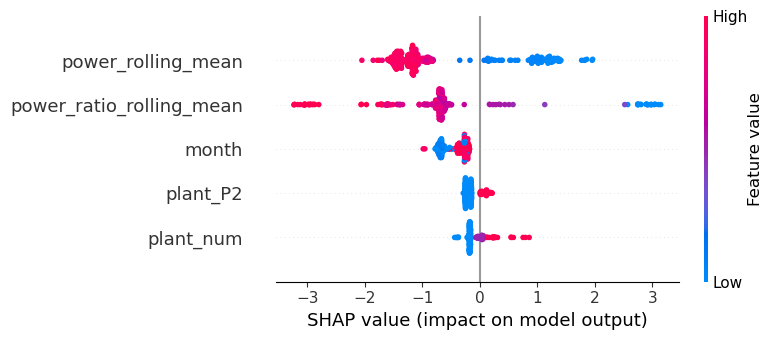


Saved: shap_values.csv — top 3 risk drivers per inverter
   inverter_id                                                   top_risk_features
0     P1_LT2_6               [power_rolling_mean, month, power_ratio_rolling_mean]
1     P1_LT2_5               [power_rolling_mean, power_ratio_rolling_mean, month]
2     P1_LT2_9               [power_rolling_mean, power_ratio_rolling_mean, month]
3     P1_LT2_4               [power_rolling_mean, power_ratio_rolling_mean, month]
4     P1_LT2_3               [power_rolling_mean, power_ratio_rolling_mean, month]
5     P1_LT2_2               [power_rolling_mean, power_ratio_rolling_mean, month]
6    P1_LT2_10               [power_rolling_mean, month, power_ratio_rolling_mean]
7     P1_LT1_0               [power_rolling_mean, power_ratio_rolling_mean, month]
8     P1_LT2_1               [power_rolling_mean, power_ratio_rolling_mean, month]
9     P1_LT2_0               [power_rolling_mean, power_ratio_rolling_mean, month]
10    P1_LT1_1               

In [11]:
# ── CELL 11: SHAP EXPLAINABILITY (XGBOOST ONLY) ────────────────────────
print('Calculating SHAP values for selected model: XGBoost')

sample_n = min(300, len(X_test))
shap_sample = X_test.sample(sample_n, random_state=42)

explainer = shap.TreeExplainer(best_model_final)
shap_vals = explainer.shap_values(shap_sample)
if isinstance(shap_vals, list):
    shap_values_arr = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
else:
    shap_values_arr = shap_vals

feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': np.abs(shap_values_arr).mean(axis=0)
}).sort_values('importance', ascending=False)

print('\nTop 5 Features by SHAP Importance:')
print(feature_importance.head().to_string(index=False))

shap.summary_plot(shap_values_arr, shap_sample, max_display=5)

# Per-inverter SHAP — latest state per inverter
current_state = daytime_full.sort_values('datetime').groupby('inverter_id').tail(1).copy()
current_anomaly_input = current_state[ANOMALY_FEATURES].fillna(0)
current_state['anomaly_score'] = -iso_forest.score_samples(current_anomaly_input)

X_current_core = current_state[CORE_FEATURES].copy()
X_current_plants = pd.get_dummies(current_state['source_plant'], prefix='plant').reindex(columns=PLANT_FEATURES, fill_value=0)
X_current = pd.concat([X_current_core.reset_index(drop=True), X_current_plants.reset_index(drop=True)], axis=1)
X_current = X_current[FEATURES].fillna(train_feature_medians).fillna(0.0)

shap_current = explainer.shap_values(X_current)
if isinstance(shap_current, list):
    shap_current = shap_current[1] if len(shap_current) > 1 else shap_current[0]

shap_per_inverter = pd.DataFrame(shap_current, columns=FEATURES)
shap_per_inverter['inverter_id'] = current_state['inverter_id'].values

feature_cols = [f for f in FEATURES if f in shap_per_inverter.columns]

def top3_features(row):
    return row[feature_cols].abs().nlargest(3).index.tolist()

shap_per_inverter['top_risk_features'] = shap_per_inverter[feature_cols].apply(top3_features, axis=1)
shap_per_inverter.to_csv('shap_values.csv', index=False)
print('\nSaved: shap_values.csv — top 3 risk drivers per inverter')
print(shap_per_inverter[['inverter_id', 'top_risk_features']].to_string())


In [ ]:
# ── CELL 12: LIVE PREDICTIONS + SAVE ARTIFACTS (PURGED FAST XGBOOST) ───
risk_labels = {0: 'No Risk', 1: 'Degradation Risk', 2: 'Shutdown Risk'}

# Score anomaly features on full latest data using train-fitted iso model.
daytime_live = daytime_full.copy()
anomaly_input_live = daytime_live[ANOMALY_FEATURES].fillna(0)
daytime_live['anomaly_flag'] = (iso_forest.predict(anomaly_input_live) == -1).astype(int)
daytime_live['anomaly_score'] = -iso_forest.score_samples(anomaly_input_live)

# Last 288 readings per inverter.
recent = daytime_live.sort_values('datetime').groupby('inverter_id').tail(288).copy()
X_recent_core = recent[CORE_FEATURES].copy()
X_recent_plants = pd.get_dummies(recent['source_plant'], prefix='plant').reindex(columns=PLANT_FEATURES, fill_value=0)
X_recent = pd.concat([X_recent_core.reset_index(drop=True), X_recent_plants.reset_index(drop=True)], axis=1)
X_recent = X_recent[FEATURES].fillna(train_feature_medians).fillna(0.0)

recent_probs_raw = best_model_final.predict_proba(X_recent)[:, 1]
recent_probs = (1 - recent_probs_raw) if score_flipped else recent_probs_raw
recent_multi = xgb_multi.predict(X_recent)

recent['risk_score'] = recent_probs
recent['risk_category'] = [risk_labels[r] for r in recent_multi]

live_df = recent.groupby('inverter_id').agg(
    last_reading=('datetime', 'max'),
    risk_score=('risk_score', 'max'),
    avg_risk_score=('risk_score', 'mean'),
    anomaly_flag=('anomaly_flag', 'max'),
    current_temp=('temp', 'last'),
    current_power=('power', 'last'),
    temp_24hr_avg=('temp_rolling_mean', 'last'),
    power_ratio_24hr=('power_ratio_rolling_mean', 'last'),
).reset_index()

# Live deployment uses alert-rate transferred from dev (quantile-based, robust to score-scale drift).
live_alert_rate = float(np.clip(deployment_alert_rate, min_pred_rate, max_pred_rate))
live_threshold = float(np.quantile(recent['risk_score'].values, max(0.0, 1.0 - live_alert_rate)))
live_df['fault_predicted'] = (live_df['risk_score'] >= live_threshold).astype(int)
live_df['risk_level'] = pd.cut(
    live_df['risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['LOW', 'MEDIUM', 'HIGH'],
    include_lowest=True
)

worst_per_inv = recent.loc[recent.groupby('inverter_id')['risk_score'].idxmax()]
live_df = live_df.merge(worst_per_inv[['inverter_id', 'risk_category']], on='inverter_id', how='left')
live_df = live_df.sort_values('risk_score', ascending=False)

print('='*70)
print('LIVE INVERTER RISK DASHBOARD — as of latest data')
print(f'Selected binary model: XGBoost | Live threshold={live_threshold:.4f} | Score flipped: {score_flipped}')
print(f'Deployment alert rate target: {live_alert_rate*100:.3f}%')
print('='*70)
print(live_df.to_string(index=False))

# Save all artifacts.
pickle.dump(best_model_final, open('model.pkl', 'wb'))
pickle.dump(xgb_multi, open('model_multi.pkl', 'wb'))
pickle.dump(iso_forest, open('anomaly_model.pkl', 'wb'))
pickle.dump(None, open('scaler.pkl', 'wb'))

with open('features.json', 'w') as f:
    json.dump(FEATURES, f)

live_df.to_csv('live_predictions.csv', index=False)

# Full hold-out test predictions for dashboard trend charts.
test_meta = model_df.loc[X_test.index, ['inverter_id', 'datetime']].copy()
pred_df = X_test.copy()
pred_df['inverter_id'] = test_meta['inverter_id'].values
pred_df['datetime'] = test_meta['datetime'].values
pred_df['risk_score'] = test_probs
pred_df['predicted_fault'] = test_preds
pred_df['actual_fault'] = y_test.values
pred_df.to_csv('predictions.csv', index=False)

# Inverter summary.
inv_summary = pred_df.groupby('inverter_id').agg(
    avg_risk_score=('risk_score', 'mean'),
    max_risk_score=('risk_score', 'max'),
    fault_count=('predicted_fault', 'sum'),
    total_readings=('predicted_fault', 'count'),
    avg_temp=('temp', 'mean'),
    avg_power=('power', 'mean')
).reset_index()
inv_summary['risk_level'] = pd.cut(
    inv_summary['avg_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['LOW', 'MEDIUM', 'HIGH'],
    include_lowest=True
)
inv_summary.to_csv('inverter_summary.csv', index=False)

print('\nSaved artifacts:')
print('  model.pkl             → Flask API (XGBoost binary model)')
print('  model_multi.pkl       → Flask API (XGBoost multi-class model)')
print('  anomaly_model.pkl     → Flask API (anomaly detector)')
print('  scaler.pkl            → None (not required for XGBoost)')
print('  features.json         → Flask API')
print('  live_predictions.csv  → Dashboard (current inverter states)')
print('  predictions.csv       → Dashboard (trend charts)')
print('  inverter_summary.csv  → Dashboard cards + GenAI layer')
print('  shap_values.csv       → GenAI layer (explanation driver)')
